# Lecture 02 GARCH

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from pandas_datareader import DataReader
from datetime import datetime
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
def garch(param, *args):
    # Initialize Params
    mu = param[0]
    omega = param[1]
    alpha = param[2]
    beta = param[3]
    GARCH_Dens, sigma2, F, v = {}, {}, {}, {} 
    # intialize values 
    sigma2[0] = np.var(Y)
    Likelihood = 0
    for t in range(1,T):
        sigma2[t] = omega + alpha*((Y[t-1]-mu)**2)+beta*(sigma2[t-1])
        F[t] = Y[t] - mu-np.sqrt(sigma2[t])*np.random.normal(0,1,1)
        v[t] = sigma2[t]
        GARCH_Dens[t] = (1/2)*np.log(2*np.pi)+(1/2)*np.log(v[t])+\
                    (1/2)*(F[t]/v[t])     
        Likelihood += GARCH_Dens[t]  
    
    return Likelihood

In [3]:
def garch_path(params, *args):
    mu = params[0]
    omega = params[1]
    alpha = params[2]
    beta = params[3]
    sigma2, path = {}, {}
    # initialzie volatility and path
    sigma2[0] = np.var(Y)
    path[0] = np.array([Y[0]])
    for t in range(1,T):
        sigma2[t] = omega + alpha*((Y[t-1]-mu)**2)+beta*(sigma2[t-1]); 
        path[t] = mu+np.sqrt(sigma2[t])*np.random.normal(0,1,1)    
        
    return path, sigma2    

[*********************100%***********************]  1 of 1 completed


         Current function value: -386.785770
         Iterations: 1
         Function evaluations: 155
         Gradient evaluations: 29
RMSE values is: 0.03641349770295606%


/usr/local/anaconda3/lib/python3.12/site-packages/scipy/optimize/_minimize.py:708: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


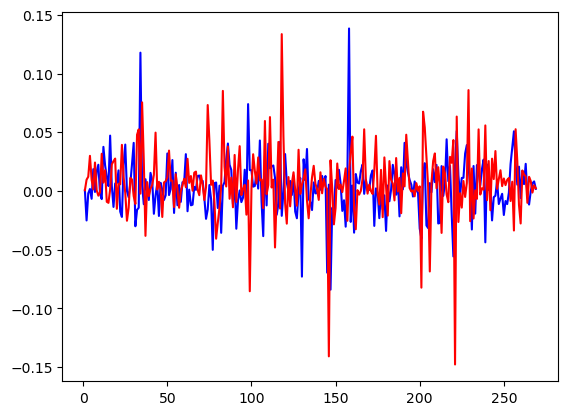

In [4]:
start_date = datetime(2023,1,1)
end_date = datetime(2024,1,31)
stock_symbol = 'PANW'
stock = yf.download(stock_symbol,start_date ,end_date)
Y = np.diff(np.log(stock['Adj Close'].values))
T = Y.shape[0]
param0 = np.array([np.mean(Y), np.var(Y)/900, 1.2, 0.25])
results = minimize(garch, param0, method='BFGS', tol=1e-2, options={'disp': True})
param_star = results.x

path, vol = garch_path(param_star, Y, T)
Y_GARCH = path.values()
timevec = np.linspace(1,T,T)
plt.plot(timevec, Y,'b',timevec, Y_GARCH,'r')

# Extracting the dictionary values into a list (in the same order as keys)
GARCH_prediction = list(Y_GARCH)

# Calculate RMSE
RMSE = np.sqrt(np.mean((np.array(GARCH_prediction ) - np.array(Y))**2))
print(f'RMSE values is: {RMSE}%')

In [5]:
param_star

array([3.36973872e-03, 1.26995644e-06, 1.20001207e+00, 2.49989761e-01])